In [109]:
import pandas as pd

### Phase 1: Import & Load Data
In this phase, we ensure the data is correctly loaded into our newly named DataFrames and perform a quick check of the contents.

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confirming data load for Career_RIASEC_df
print("Career_RIASEC_df info:")
display(Career_RIASEC_df.info())
display(Career_RIASEC_df.head())

# Confirming data load for Career_Education_df
print("\nCareer_Education_df info:")
display(Career_Education_df.info())
display(Career_Education_df.head())

Career_RIASEC_df info:
<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 0 to 2399
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Math_Score           2400 non-null   float64
 1   Science_Score        2400 non-null   float64
 2   Programming_Skill    2400 non-null   int64  
 3   Communication_Skill  2400 non-null   int64  
 4   Logical_Ability      2400 non-null   int64  
 5   R_score              2400 non-null   float64
 6   I_score              2400 non-null   float64
 7   A_score              2400 non-null   float64
 8   S_score              2400 non-null   float64
 9   E_score              2400 non-null   float64
 10  C_score              2400 non-null   float64
 11  Career               2400 non-null   object 
 12  Career_Encoded       2400 non-null   int64  
dtypes: float64(8), int64(4), object(1)
memory usage: 262.5+ KB


None

,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score,Career,Career_Encoded
0,0.860986,1.056056,3,4,2,1.050184,-0.704477,0.977317,-0.420269,2.240181,-1.034697,Entrepreneur,3
1,0.757735,-1.190439,3,3,5,-0.547391,-1.406468,-1.137229,-0.052821,0.228795,1.227279,Accountant,0
2,-1.513792,-0.897418,4,4,2,-0.547391,-0.704477,0.448680,1.049523,0.228795,-1.411693,Teacher,5
3,1.480493,-0.506723,2,2,4,-1.079917,-1.406468,-1.137229,-1.155165,-0.978036,0.850283,Accountant,0
4,0.860986,-0.799744,2,4,4,2.115234,-1.055472,-0.079956,-1.522613,1.033350,-1.034697,Entrepreneur,3



Career_Education_df info:
<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Education Level             4999 non-null   object
 1   Specialization              4999 non-null   object
 2   Skills                      4999 non-null   object
 3   Certifications              4999 non-null   object
 4   CGPA/Percentage             4999 non-null   int64 
 5   Recommended Career          4999 non-null   object
 6   Education Level_Encoded     4999 non-null   int64 
 7   Specialization_Encoded      4999 non-null   int64 
 8   Certifications_Encoded      4999 non-null   int64 
 9   Recommended Career_Encoded  4999 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 429.6+ KB


None

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career,Education Level_Encoded,Specialization_Encoded,Certifications_Encoded,Recommended Career_Encoded
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst,0,5,7,0
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer,1,7,0,11
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst,2,1,5,3
3,Bachelor's,Computer Science,Communication,No Certification,75,Clerk,0,3,6,1
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant,3,1,7,9


### Phase 2: Data Cleaning & Preprocessing
In this phase, we handle missing values and prepare categorical features for further analysis.

In [111]:
# 1. Handling missing values in Certifications
Career_Education_df['Certifications'] = Career_Education_df['Certifications'].fillna('No Certification')

# 2. Check for duplicates
print(f"Duplicates in RIASEC: {Career_RIASEC_df.duplicated().sum()}")
print(f"Duplicates in Education: {Career_Education_df.duplicated().sum()}")

# 3. Quick look at unique values for key columns
print("\nUnique Specializations:", Career_Education_df['Specialization'].nunique())
print("Unique Education Levels:", Career_Education_df['Education Level'].nunique())

display(Career_Education_df.head())

Duplicates in RIASEC: 0
Duplicates in Education: 0

Unique Specializations: 8
Unique Education Levels: 5


,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career,Education Level_Encoded,Specialization_Encoded,Certifications_Encoded,Recommended Career_Encoded
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst,0,5,7,0
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer,1,7,0,11
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst,2,1,5,3
3,Bachelor's,Computer Science,Communication,No Certification,75,Clerk,0,3,6,1
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant,3,1,7,9


### Phase 2: Dataset Inspection
In this section, we verify the structure and statistical distribution of `Career_RIASEC_df` and `Career_Education_df`.

In [112]:
def inspect_dataframe(df, name):
    print(f"--- Inspection for {name} ---")
    print(f"Shape: {df.shape}")
    print("\nColumn Names:", df.columns.tolist())
    print("\nData Types and Nulls:")
    df.info()
    print("\nStatistical Summary:")
    display(df.describe(include='all'))
    print("\nMissing Values Summary:")
    print(df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())
    print("\n")

inspect_dataframe(Career_RIASEC_df, "Career_RIASEC_df")
inspect_dataframe(Career_Education_df, "Career_Education_df")

--- Inspection for Career_RIASEC_df ---
Shape: (2400, 13)

Column Names: ['Math_Score', 'Science_Score', 'Programming_Skill', 'Communication_Skill', 'Logical_Ability', 'R_score', 'I_score', 'A_score', 'S_score', 'E_score', 'C_score', 'Career', 'Career_Encoded']

Data Types and Nulls:
<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 0 to 2399
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Math_Score           2400 non-null   float64
 1   Science_Score        2400 non-null   float64
 2   Programming_Skill    2400 non-null   int64  
 3   Communication_Skill  2400 non-null   int64  
 4   Logical_Ability      2400 non-null   int64  
 5   R_score              2400 non-null   float64
 6   I_score              2400 non-null   float64
 7   A_score              2400 non-null   float64
 8   S_score              2400 non-null   float64
 9   E_score              2400 non-null   float64
 10  C_score 

,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score,Career,Career_Encoded
count,2.400000e+03,2.400000e+03,2400.000000,2400.000000,2400.000000,2.400000e+03,2.400000e+03,2.400000e+03,2.400000e+03,2.400000e+03,2.400000e+03,2400,2400.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Entrepreneur,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400,NaN
mean,4.692543e-16,5.329071e-17,3.224167,3.510000,3.728333,5.255056e-17,7.993606e-17,-5.625130e-17,1.006602e-16,8.881784e-18,1.731948e-16,NaN,2.500000
std,1.000208e+00,1.000208e+00,0.954007,1.015872,1.027117,1.000208e+00,1.000208e+00,1.000208e+00,1.000208e+00,1.000208e+00,1.000208e+00,NaN,1.708181
min,-2.030048e+00,-1.874155e+00,2.000000,2.000000,2.000000,-1.612442e+00,-1.757463e+00,-1.665866e+00,-1.522613e+00,-1.380314e+00,-1.788689e+00,NaN,0.000000
25%,-6.877821e-01,-7.997442e-01,2.000000,3.000000,3.000000,-5.473915e-01,-1.055472e+00,-6.085928e-01,-7.877166e-01,-5.757593e-01,-1.034697e+00,NaN,1.000000
50%,1.382275e-01,1.769929e-01,3.000000,4.000000,4.000000,-1.486633e-02,-2.486217e-03,-7.995627e-02,-4.202686e-01,-1.734820e-01,9.629105e-02,NaN,2.500000
75%,7.577348e-01,8.607089e-01,4.000000,4.000000,4.250000,5.176588e-01,1.050500e+00,4.486803e-01,1.049523e+00,2.287952e-01,8.502830e-01,NaN,4.000000



Missing Values Summary:
Math_Score             0
Science_Score          0
Programming_Skill      0
Communication_Skill    0
Logical_Ability        0
R_score                0
I_score                0
A_score                0
S_score                0
E_score                0
C_score                0
Career                 0
Career_Encoded         0
dtype: int64

Duplicate Rows: 0


--- Inspection for Career_Education_df ---
Shape: (4999, 10)

Column Names: ['Education Level', 'Specialization', 'Skills', 'Certifications', 'CGPA/Percentage', 'Recommended Career', 'Education Level_Encoded', 'Specialization_Encoded', 'Certifications_Encoded', 'Recommended Career_Encoded']

Data Types and Nulls:
<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Education Level             4999 non-null   object
 1   Specialization            

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career,Education Level_Encoded,Specialization_Encoded,Certifications_Encoded,Recommended Career_Encoded
count,4999,4999,4999,4999,4999.000000,4999,4999.000000,4999.000000,4999.000000,4999.000000
unique,5,8,757,8,NaN,12,NaN,NaN,NaN,NaN
top,Master's,Engineering,Accounting,Mental Health Basics,NaN,Clerk,NaN,NaN,NaN,NaN
freq,1027,668,204,673,NaN,432,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,77.478096,NaN,1.985397,3.509702,3.526105,5.512302
std,NaN,NaN,NaN,NaN,10.396630,NaN,1.409248,2.262278,2.297603,3.439670
min,NaN,NaN,NaN,NaN,60.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,68.000000,NaN,1.000000,2.000000,1.000000,3.000000
50%,NaN,NaN,NaN,NaN,77.000000,NaN,2.000000,4.000000,4.000000,6.000000
75%,NaN,NaN,NaN,NaN,87.000000,NaN,3.000000,5.000000,5.000000,8.000000



Missing Values Summary:
Education Level               0
Specialization                0
Skills                        0
Certifications                0
CGPA/Percentage               0
Recommended Career            0
Education Level_Encoded       0
Specialization_Encoded        0
Certifications_Encoded        0
Recommended Career_Encoded    0
dtype: int64

Duplicate Rows: 0




### Finalizing Data Cleaning
Removing duplicate records to prevent bias in further analysis.

In [113]:
# Dropping duplicates
Career_RIASEC_df = Career_RIASEC_df.drop_duplicates()
Career_Education_df = Career_Education_df.drop_duplicates()

print(f"Final shape of Career_RIASEC_df: {Career_RIASEC_df.shape}")
print(f"Final shape of Career_Education_df: {Career_Education_df.shape}")

Final shape of Career_RIASEC_df: (2400, 13)
Final shape of Career_Education_df: (4999, 10)


### Phase 3: Descriptive Analysis (EDA)
In this phase, we explore the distributions of our variables and the balance of our target career classes.

In [114]:
# 1. Target Class Distribution
print("Career Distribution in RIASEC Dataset:")
display(Career_RIASEC_df['Career'].value_counts())

print("\nRecommended Career Distribution in Education Dataset:")
display(Career_Education_df['Recommended Career'].value_counts())

Career Distribution in RIASEC Dataset:


,count
Career,
Entrepreneur,400
Accountant,400
Teacher,400
Software Engineer,400
Doctor,400
Data Scientist,400



Recommended Career Distribution in Education Dataset:


,count
Recommended Career,
Clerk,432
Marketing Executive,432
ML Engineer,428
Research Scientist,419
Software Engineer,417
School Counselor,417
Sales Assistant,413
Financial Analyst,413
Data Entry Operator,413


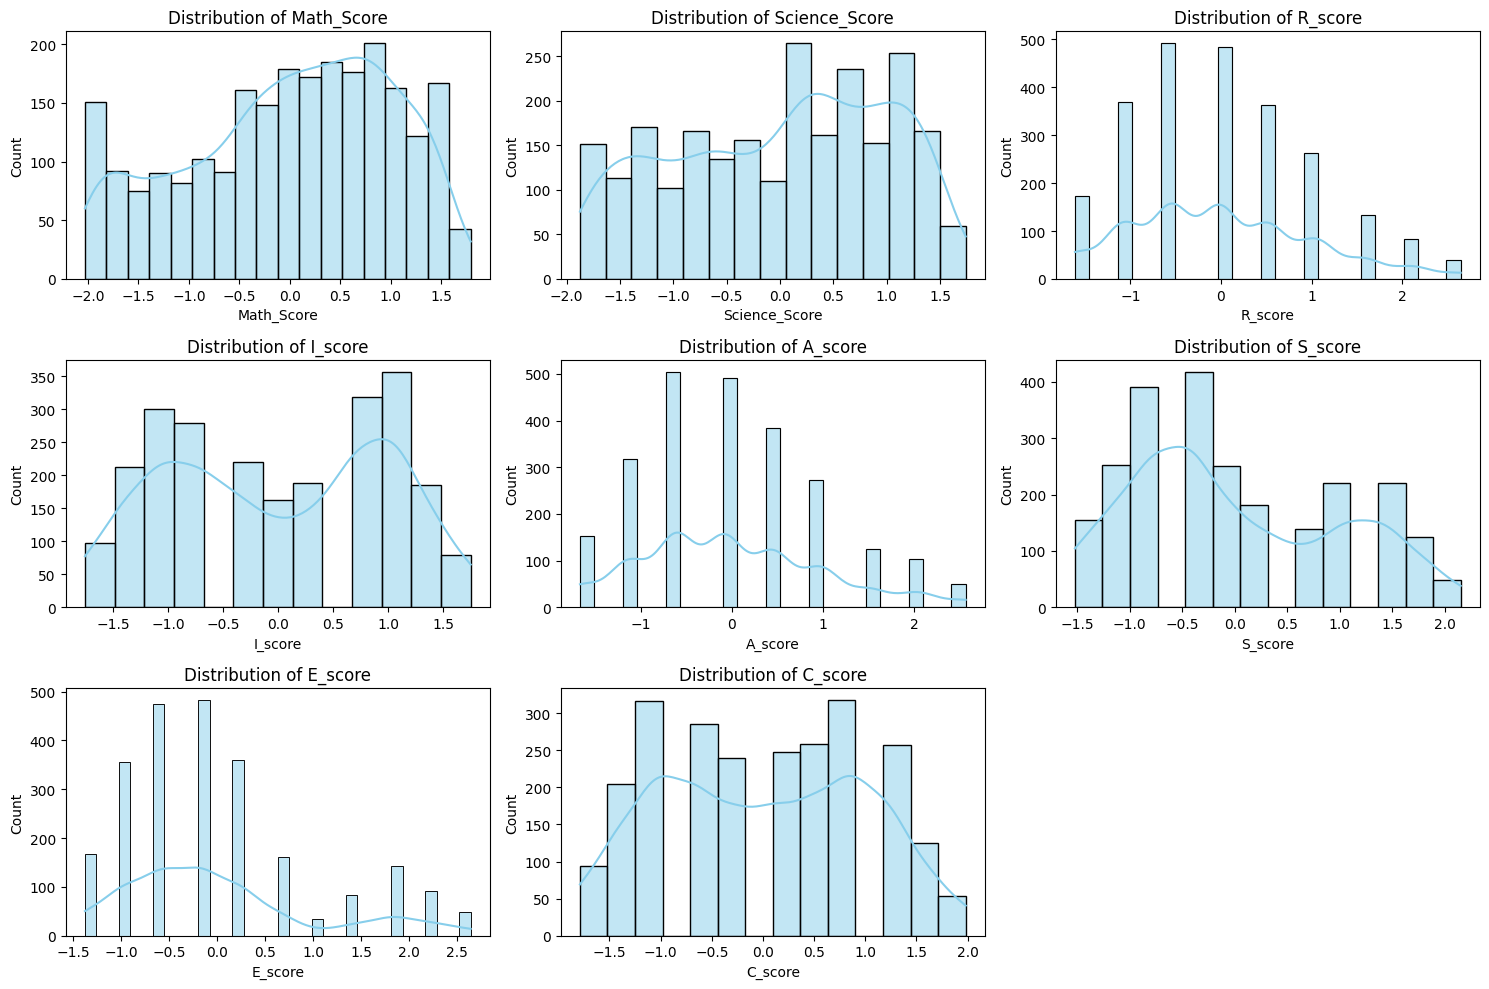

In [115]:
# 2. Visualizing Numerical Distributions for RIASEC Scores
numerical_cols = ['Math_Score', 'Science_Score', 'R_score', 'I_score', 'A_score', 'S_score', 'E_score', 'C_score']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(Career_RIASEC_df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

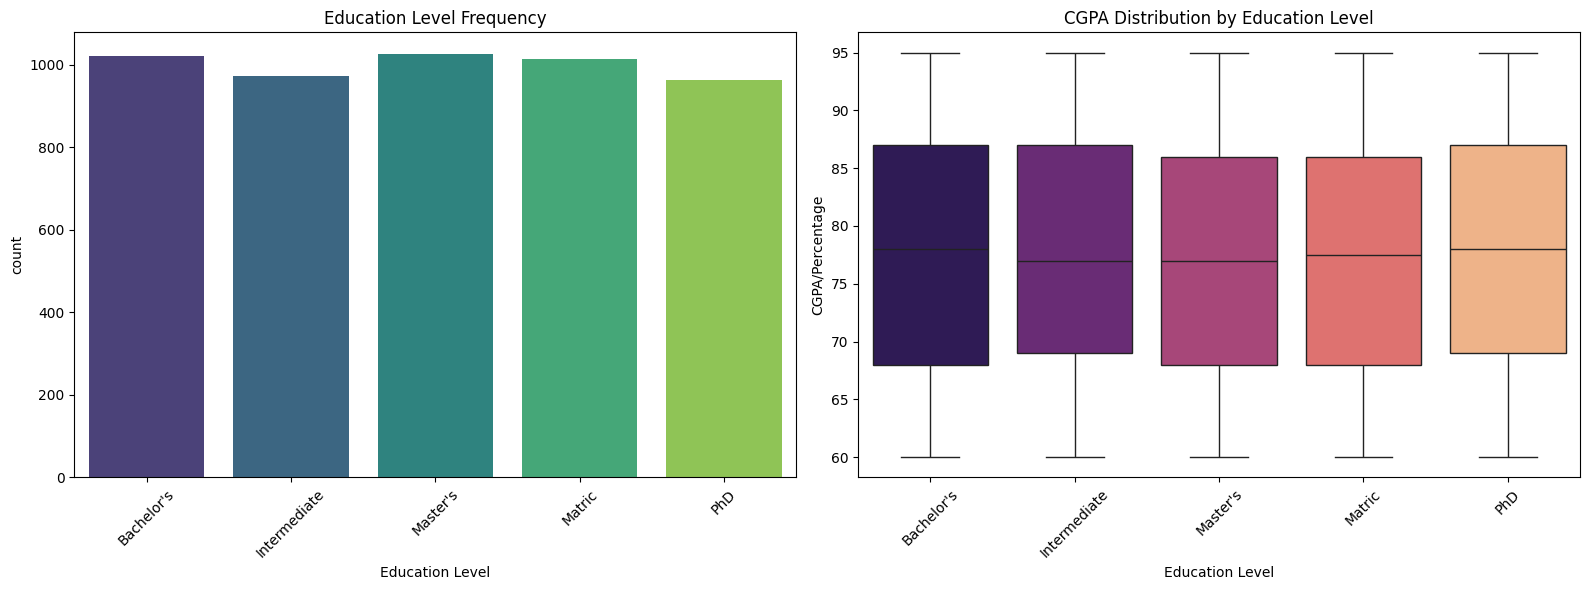

In [116]:
# 3. Visualizing Education Level and CGPA
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=Career_Education_df, x='Education Level', ax=ax[0], palette='viridis', hue='Education Level', legend=False)
ax[0].set_title('Education Level Frequency')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=Career_Education_df, y='CGPA/Percentage', x='Education Level', ax=ax[1], palette='magma', hue='Education Level', legend=False)
ax[1].set_title('CGPA Distribution by Education Level')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Phase 3.1: Correlation Analysis and Feature Engineering
In this step, we examine relationships between numerical features and process the text-based skills data.

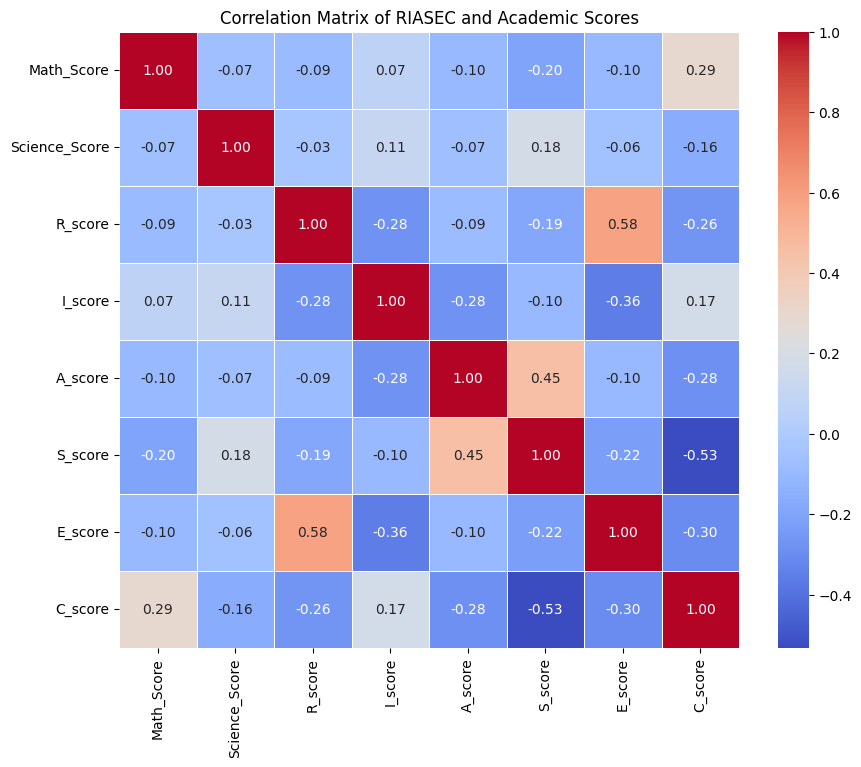

In [117]:
# 4. Correlation Heatmap for RIASEC Dataset
plt.figure(figsize=(10, 8))
# Using the list defined previously in the session
corr_matrix = Career_RIASEC_df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of RIASEC and Academic Scores')
plt.show()

Top 10 Most Frequent Skills:
Skills
Python                1031
Accounting            1013
Data Analysis         1007
MS Office             1005
Financial Analysis     997
Marketing              992
SQL                    992
Counseling             986
Communication          970
Machine Learning       950
Name: count, dtype: int64


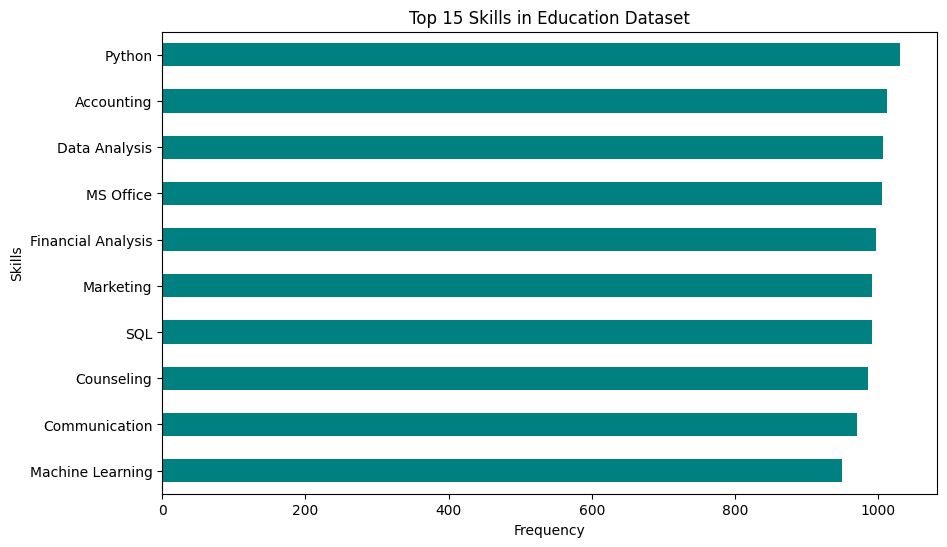

In [118]:
# 5. Parsing the 'Skills' column
from collections import Counter

# Split skills by comma and strip whitespace
all_skills = Career_Education_df['Skills'].str.split(',').explode().str.strip()
skill_counts = all_skills.value_counts()

print("Top 10 Most Frequent Skills:")
print(skill_counts.head(10))

# Visualize top skills
plt.figure(figsize=(10, 6))
skill_counts.head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Skills in Education Dataset')
plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.show()

### Phase 4: Data Preprocessing
In this phase, we prepare the data for machine learning models by encoding categorical variables and scaling numerical features.

In [119]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Encoding Categorical Variables in Career_Education_df
le = LabelEncoder()

# We'll encode the main categorical descriptors and the target career
categorical_cols_edu = ['Education Level', 'Specialization', 'Certifications', 'Recommended Career']
for col in categorical_cols_edu:
    Career_Education_df[col + '_Encoded'] = le.fit_transform(Career_Education_df[col])

# 2. Encoding Target in Career_RIASEC_df
Career_RIASEC_df['Career_Encoded'] = le.fit_transform(Career_RIASEC_df['Career'])

# 3. Scaling Numerical Features in RIASEC dataset
scaler = StandardScaler()
numerical_cols = ['Math_Score', 'Science_Score', 'R_score', 'I_score', 'A_score', 'S_score', 'E_score', 'C_score']
Career_RIASEC_df[numerical_cols] = scaler.fit_transform(Career_RIASEC_df[numerical_cols])

print("Preprocessing complete. Categorical columns encoded and numerical features scaled.")
display(Career_RIASEC_df.head())

Preprocessing complete. Categorical columns encoded and numerical features scaled.


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score,Career,Career_Encoded
0,0.860986,1.056056,3,4,2,1.050184,-0.704477,0.977317,-0.420269,2.240181,-1.034697,Entrepreneur,3
1,0.757735,-1.190439,3,3,5,-0.547391,-1.406468,-1.137229,-0.052821,0.228795,1.227279,Accountant,0
2,-1.513792,-0.897418,4,4,2,-0.547391,-0.704477,0.448680,1.049523,0.228795,-1.411693,Teacher,5
3,1.480493,-0.506723,2,2,4,-1.079917,-1.406468,-1.137229,-1.155165,-0.978036,0.850283,Accountant,0
4,0.860986,-0.799744,2,4,4,2.115234,-1.055472,-0.079956,-1.522613,1.033350,-1.034697,Entrepreneur,3


### Phase 4.1: Outlier Detection and Final Encoding
Before proceeding to modeling, we'll check for extreme values in our scaled scores and finalize the feature sets.

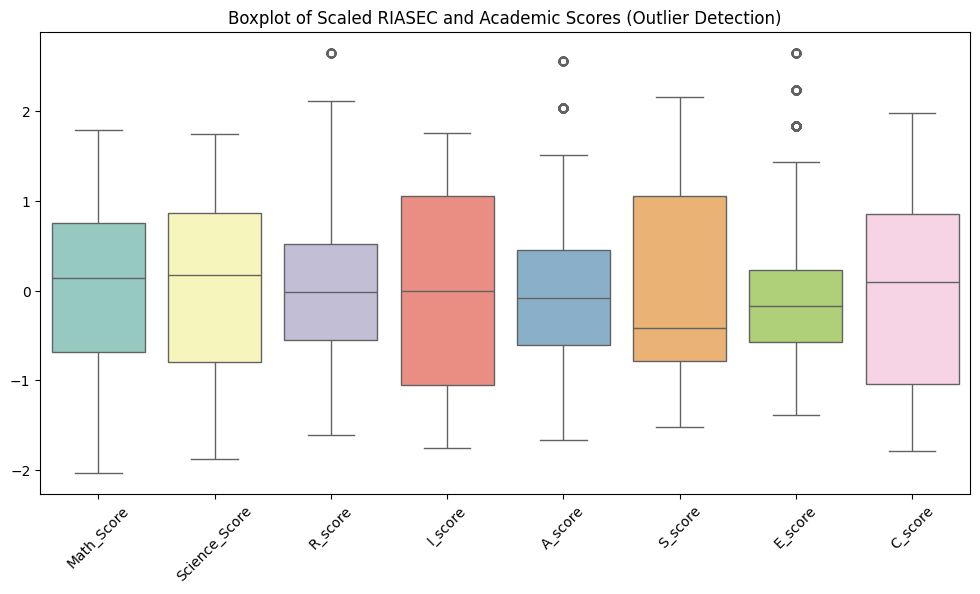

In [120]:
# 4. Checking for Outliers in the RIASEC dataset
plt.figure(figsize=(12, 6))
sns.boxplot(data=Career_RIASEC_df[numerical_cols], palette='Set3')
plt.title('Boxplot of Scaled RIASEC and Academic Scores (Outlier Detection)')
plt.xticks(rotation=45)
plt.show()

In [121]:
# 5. Final Feature Selection for Career_Education_df
# Displaying the first few rows of the fully preprocessed Education dataset
print("Preprocessed Career_Education_df sample:")
display(Career_Education_df.filter(like='_Encoded').head())

Preprocessed Career_Education_df sample:


,Education Level_Encoded,Specialization_Encoded,Certifications_Encoded,Recommended Career_Encoded
0,0,5,7,0
1,1,7,0,11
2,2,1,5,3
3,0,3,6,1
4,3,1,7,9


### Phase 5.1: Feature & Target Separation
We separate the independent variables (features) from the dependent variable (target career) to prepare for the split.

In [122]:
# Defining Features (X) and Target (y) for the RIASEC dataset
# numerical_cols was defined as: ['Math_Score', 'Science_Score', 'R_score', 'I_score', 'A_score', 'S_score', 'E_score', 'C_score']

X = Career_RIASEC_df[numerical_cols]
y = Career_RIASEC_df['Career_Encoded']

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)
print("\nFirst 5 rows of features:")
display(X.head())

Features (X) Shape: (2400, 8)
Target (y) Shape: (2400,)

First 5 rows of features:


,Math_Score,Science_Score,R_score,I_score,A_score,S_score,E_score,C_score
0,0.860986,1.056056,1.050184,-0.704477,0.977317,-0.420269,2.240181,-1.034697
1,0.757735,-1.190439,-0.547391,-1.406468,-1.137229,-0.052821,0.228795,1.227279
2,-1.513792,-0.897418,-0.547391,-0.704477,0.448680,1.049523,0.228795,-1.411693
3,1.480493,-0.506723,-1.079917,-1.406468,-1.137229,-1.155165,-0.978036,0.850283
4,0.860986,-0.799744,2.115234,-1.055472,-0.079956,-1.522613,1.033350,-1.034697


In [123]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Defining Features and Target for RIASEC Dataset
# We use the scaled numerical scores as features
numerical_cols = ['Math_Score', 'Science_Score', 'R_score', 'I_score', 'A_score', 'S_score', 'E_score', 'C_score']
X = Career_RIASEC_df[numerical_cols]
y = Career_RIASEC_df['Career_Encoded']

# 2. Splitting the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Training the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluating the model
y_pred = rf_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       0.69      0.86      0.77        88
           2       1.00      0.98      0.99        82
           3       1.00      1.00      1.00        82
           4       0.80      0.59      0.68        83
           5       1.00      1.00      1.00        73

    accuracy                           0.90       480
   macro avg       0.91      0.90      0.90       480
weighted avg       0.91      0.90      0.90       480



### Phase 6: Train-Test Split
In this phase, we formalize the separation of our data into training and testing sets. This ensures that we can evaluate our model's performance on unseen data, preventing overfitting.

In [124]:
from sklearn.model_selection import train_test_split

# 1. Defining Features and Target
# We use the RIASEC scores and academic scores as our feature set (X)
# and the encoded Career as our target (y)
X = Career_RIASEC_df[numerical_cols]
y = Career_RIASEC_df['Career_Encoded']

# 2. Splitting the data
# We use an 80-20 split with a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verifying the split
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Displaying the first few rows of the training features
display(X_train.head())

Training set size: 1920 samples
Testing set size: 480 samples


,Math_Score,Science_Score,R_score,I_score,A_score,S_score,E_score,C_score
120,0.344730,-0.506723,-1.079917,1.050500,0.977317,-0.052821,0.228795,0.096291
283,-0.378028,-1.092765,-0.547391,-0.002486,-1.137229,-0.420269,0.228795,0.850283
1727,-0.584531,1.349077,-1.079917,1.050500,-0.608593,1.049523,-0.173482,-1.411693
1984,0.757735,0.763035,-0.547391,-0.704477,0.977317,2.151867,0.228795,-0.280705
647,0.654484,1.349077,-0.547391,1.050500,-0.608593,-0.787717,-0.173482,0.850283


### Phase 7: Model Training
In this phase, we initialize and train a **Random Forest Classifier**. This ensemble method is robust and works well for identifying the complex patterns between RIASEC traits and career paths.

In [125]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest Classifier
# We'll use 100 trees and a fixed random state for consistent results
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model on the training data
rf_model.fit(X_train, y_train)

print("Model training complete using Random Forest.")

Model training complete using Random Forest.


### Phase 8: Prediction & Evaluation
We now assess the model's performance on the unseen test set to determine its accuracy and identify any specific classes where it might be struggling.

Model Accuracy: 90.00%

Classification Report:

                   precision    recall  f1-score   support

       Accountant       0.97      1.00      0.99        72
   Data Scientist       0.69      0.86      0.77        88
           Doctor       1.00      0.98      0.99        82
     Entrepreneur       1.00      1.00      1.00        82
Software Engineer       0.80      0.59      0.68        83
          Teacher       1.00      1.00      1.00        73

         accuracy                           0.90       480
        macro avg       0.91      0.90      0.90       480
     weighted avg       0.91      0.90      0.90       480



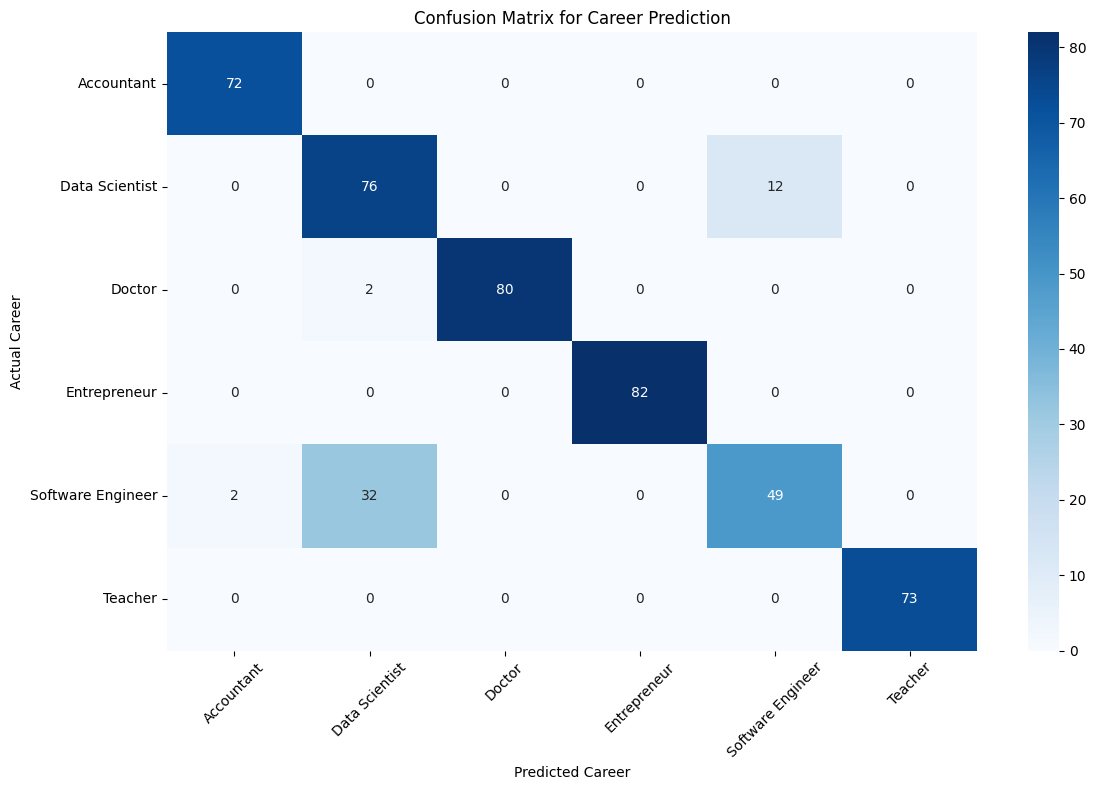

In [132]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict using test data
y_pred = rf_model.predict(X_test)

# 2. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

# 3. Classification Report
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Career")
plt.ylabel("Actual Career")

plt.title("Confusion Matrix for Career Prediction")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Phase 9: Insight Generation & Explainable AI (SHAP)
In this phase, we move beyond simple accuracy to understand *why* the model makes certain recommendations. This is critical for building trust with users.

Recommended Career: Software Engineer
(Based on Sample Index: 2037)

Reason Why the model chose this career:
- Investigative (I) Trait: Score 8 strongly influenced recommendation.
- Social (S) Trait: Score 2 strongly influenced recommendation.
- Scientific Knowledge: Score 60 strongly influenced recommendation.


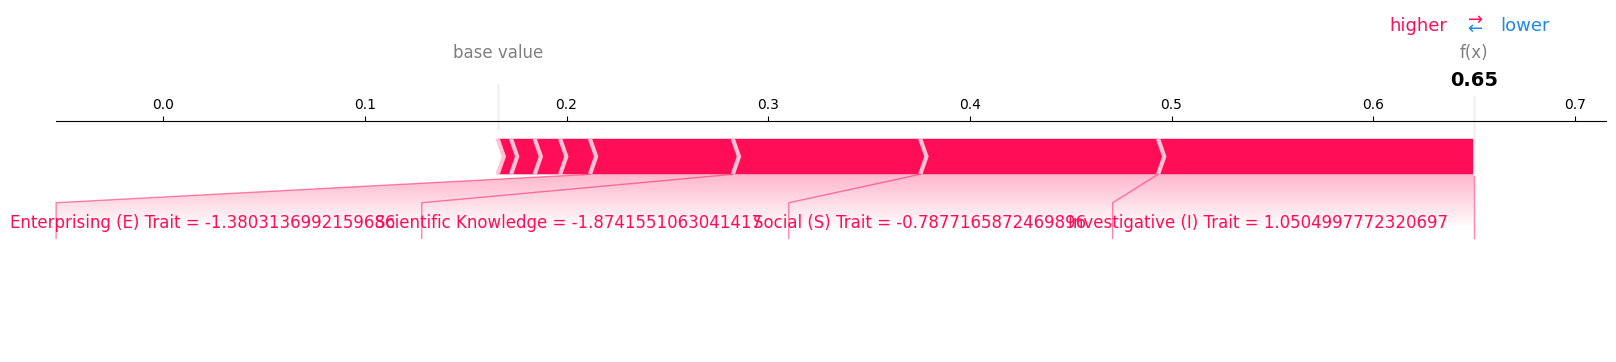

In [134]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Initialize SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# 2. Select a sample from the test set
sample_idx = X_test.index[0]
test_set_loc = X_test.index.get_loc(sample_idx)

# 3. Identify prediction
predicted_class_idx = rf_model.predict(X_test.loc[[sample_idx]])[0]
predicted_career_name = le.inverse_transform([predicted_class_idx])[0]

# 4. Extract SHAP values safely
# In many versions of SHAP, TreeExplainer returns a list for multi-class classifiers
if isinstance(shap_values, list):
    current_shap_vals = shap_values[predicted_class_idx][test_set_loc]
    base_val = explainer.expected_value[predicted_class_idx]
else:
    # If it's a newer SHAP Explanation object or a single array
    if hasattr(shap_values, 'values'):
        current_shap_vals = shap_values.values[test_set_loc, :, predicted_class_idx]
    else:
        current_shap_vals = shap_values[test_set_loc, :, predicted_class_idx]
    base_val = explainer.expected_value[predicted_class_idx]

# 5. Get top 3 features using SHAP importance (absolute impact)
top_indices = np.argsort(np.abs(current_shap_vals))[-3:][::-1]
top_features = [numerical_cols[i] for i in top_indices]

# Mapping for user-friendly labels
feature_map = {
    'I_score': 'Investigative (I) Trait',
    'S_score': 'Social (S) Trait',
    'R_score': 'Realistic (R) Trait',
    'A_score': 'Artistic (A) Trait',
    'E_score': 'Enterprising (E) Trait',
    'C_score': 'Conventional (C) Trait',
    'Math_Score': 'Mathematical Ability',
    'Science_Score': 'Scientific Knowledge',
    'Programming_Skill': 'Programming Proficiency',
    'Logical_Ability': 'Logical Reasoning'
}

print(f"Recommended Career: {predicted_career_name}")
print(f"(Based on Sample Index: {sample_idx})")
print("\nReason Why the model chose this career:")

for feat in top_features:
    # Get raw value from original dataframe before scaling for readability
    raw_val = Career_RIASEC.loc[sample_idx, feat]
    friendly_name = feature_map.get(feat, feat.replace('_', ' '))
    impact = "strongly influenced" if current_shap_vals[numerical_cols.index(feat)] > 0 else "factored into"
    print(f"- {friendly_name}: Score {raw_val} {impact} recommendation.")

# 6. Generate the SHAP force plot
shap.initjs()
shap.force_plot(
    base_val,
    current_shap_vals,
    X_test.loc[sample_idx].values,
    feature_names=[feature_map.get(c, c) for c in numerical_cols],
    matplotlib=True
)
plt.show()

### Phase 10: Model Improvement
In this phase, we optimize our model selection by tuning hyperparameters and comparing the Random Forest against a Logistic Regression baseline.

In [129]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Hyperparameter Tuning for Random Forest
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                               param_distributions=param_dist,
                               n_iter=10, cv=3, random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_
rf_acc = accuracy_score(y_test, best_rf.predict(X_test))

print(f"Best RF Parameters: {rf_random.best_params_}")
print(f"Tuned RF Accuracy: {rf_acc:.2%}")

Best RF Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10, 'criterion': 'gini'}
Tuned RF Accuracy: 90.00%


In [130]:
# 2. Logistic Regression Comparison
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))

print(f"Logistic Regression Accuracy: {lr_acc:.2%}")

# 3. Final Model Selection
if lr_acc > rf_acc:
    final_model = lr_model
    print("\nDecision: Logistic Regression selected as the final model.")
else:
    final_model = best_rf
    print("\nDecision: Tuned Random Forest selected as the final model.")

Logistic Regression Accuracy: 89.79%

Decision: Tuned Random Forest selected as the final model.


### Phase 11: Model Persistence
In this final phase, we export our trained model and preprocessing objects (Scaler and Label Encoder) to pickle files for deployment.

In [131]:
import pickle

# 1. Save the final selected model
with open('career_recommendation_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# 2. Save the scaler used for RIASEC scores
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save the label encoder for career names
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model persistence complete!")
print("Files generated: career_recommendation_model.pkl, scaler.pkl, label_encoder.pkl")

Model persistence complete!
Files generated: career_recommendation_model.pkl, scaler.pkl, label_encoder.pkl


### Test a Random User
Use this cell to see how the model recommends different careers for different profiles.

User Profile (Index 2197) Recommended Career: DATA SCIENTIST
--------------------------------------------------
* Investigative (I) Trait: 7
* Mathematical Ability: 83
* Conventional (C) Trait: 5


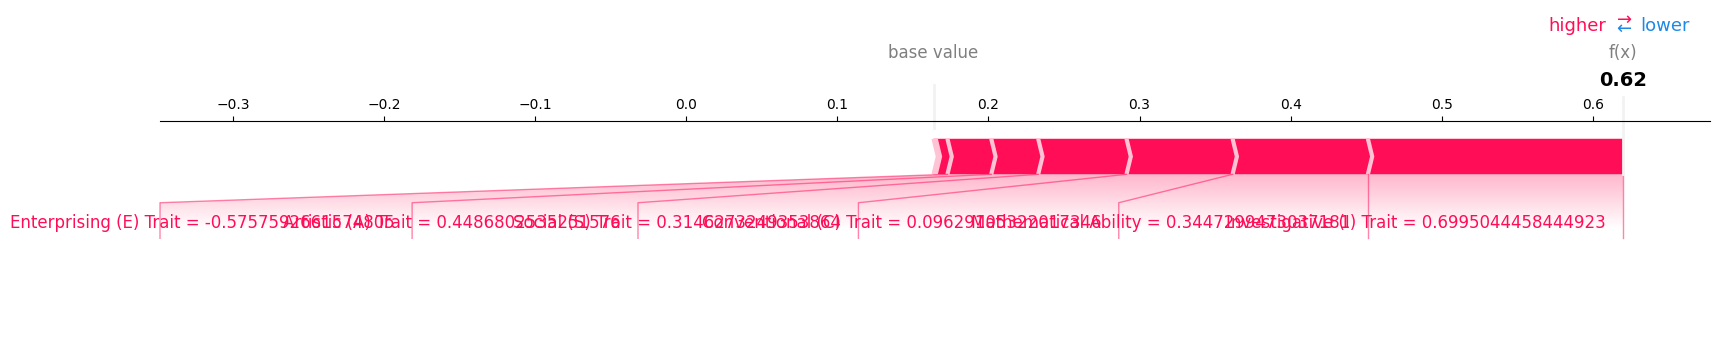

In [144]:
import random

# 1. Pick a random index from the test set
random_idx = random.choice(X_test.index)
test_loc = X_test.index.get_loc(random_idx)

# 2. Predict for this random user
pred_idx = rf_model.predict(X_test.loc[[random_idx]])[0]
pred_name = le.inverse_transform([pred_idx])[0]

# 3. Extract SHAP values for this specific prediction
if isinstance(shap_values, list):
    s_vals = shap_values[pred_idx][test_loc]
    b_val = explainer.expected_value[pred_idx]
else:
    s_vals = shap_values.values[test_loc, :, pred_idx] if hasattr(shap_values, 'values') else shap_values[test_loc, :, pred_idx]
    b_val = explainer.expected_value[pred_idx]

# 4. Display results
print(f"User Profile (Index {random_idx}) Recommended Career: {pred_name.upper()}")
print("-" * 50)

# Get top 3 factors
top_factors = np.argsort(np.abs(s_vals))[-3:][::-1]
for i in top_factors:
    f_name = numerical_cols[i]
    f_val = Career_RIASEC.loc[random_idx, f_name]
    print(f"* {feature_map.get(f_name, f_name)}: {f_val}")

# 5. Visualize
shap.force_plot(b_val, s_vals, X_test.loc[random_idx].values,
                feature_names=[feature_map.get(c, c) for c in numerical_cols],
                matplotlib=True)